In [110]:
# import necessary lib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.model_selection import train_test_split


In [111]:
# load dataset

dataset=pd.read_csv("Ice_cream selling data.csv")

In [112]:
dataset.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


# Using Simple Linear Regression

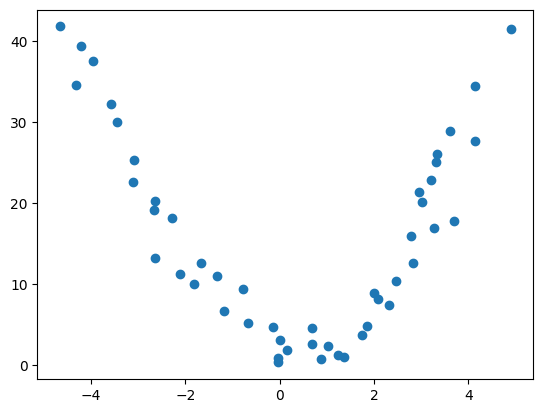

In [113]:
# Ploting the imitial points
plt.scatter(dataset['Temperature (°C)'],dataset['Ice Cream Sales (units)'])

In [114]:
# The Follwing Curve is a non linear curve.
# Lets First Try to implement a Simple Liner Regression and find a best fit line

# Split Dataset
X=dataset[["Temperature (°C)"]]
y=dataset['Ice Cream Sales (units)']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [115]:
X_test

,Temperature (°C)
13,-1.818938
45,3.704057
47,4.133534
44,3.610778
17,-0.773330
27,1.024181
26,0.874905
25,0.693599
31,1.850552
19,-0.149635


In [116]:
# Mean and Standard deviation
dataset['Ice Cream Sales (units)'].mean()
dataset['Ice Cream Sales (units)'].std()

np.float64(12.26468232652906)

In [117]:
# Standardization: As Mean!=0 and sd!=1
scaler=StandardScaler()
X_train=scaler.fit_transform(X=X_train)
X_test=scaler.transform(X=X_test)

In [118]:
X_train.mean()

np.float64(3.0839528461809905e-17)

In [119]:
# Use Simple Linear Regression
regression=LinearRegression()
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [120]:
regression.intercept_

np.float64(17.147880566695633)

In [121]:
regression.coef_

array([-2.79788264])

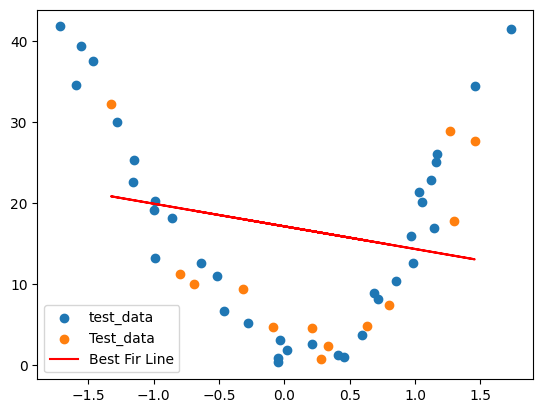

In [122]:
plt.scatter(X_train,y_train,label='test_data')
plt.scatter(X_test,y_test,label='Test_data')
plt.plot(X_test,regression.predict(X_test),'r',label='Best Fir Line')
plt.legend()
plt.show()

In [123]:
# Using Simple Regression Lets Check Accuracy
y_prediction=regression.predict(X_test)
print(r2_score(y_pred=y_prediction,y_true=y_test))

-0.2463089202933728


In [124]:
y_prediction

array([19.08359799, 13.50731512, 13.07369502, 13.60149407, 18.02790203,
       16.21304815, 16.3637642 , 16.54681966, 15.37870391, 17.39818922,
       19.37935639, 20.86019151, 14.90614879])

# Implementing Polynomial Liner Regression

In [125]:
# The accuracy is in negative so now we will use polynomial regression

# Implementation using sklearn pipeline concept

dataset.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [126]:
# Implement Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [147]:
def polynomial_Regression(degree):

    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linreg', LinearRegression())
    ])

    pipe.fit(X_train, y_train)

    # Smooth X range (IMPORTANT)
    X_curve = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
    y_curve = pipe.predict(X_curve)

    y_test_pred = pipe.predict(X_test)
    print('R2 Score:', r2_score(y_test, y_test_pred))


    # Plot
    plt.scatter(X_train, y_train, label='Train data')
    plt.scatter(X_test, y_test, label='Test data')
    plt.plot(X_curve, y_curve, 'r', linewidth=2, label='Best fit curve')

    plt.legend()
    plt.xlabel('X')
    plt.ylabel('y')
    plt.show()


R2 Score: 0.8715616916590958


d:\Udemy\DataScience\Python\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


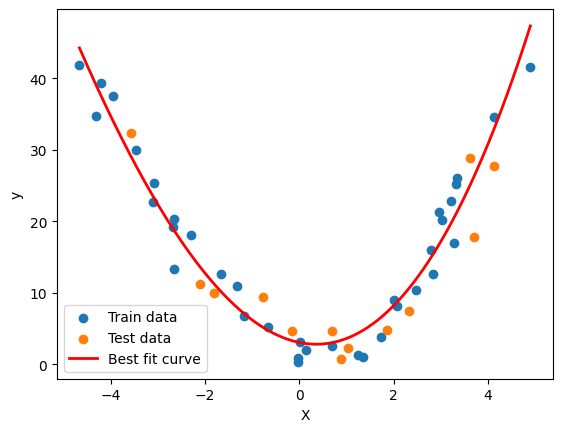

In [155]:
polynomial_Regression(3)